<a href="https://colab.research.google.com/github/MKdentist/deep-learning-course/blob/main/Ethnicity_Age_Gender_Prediction_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.20.0


In [2]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("mkk")

print("Kaggle credentials loaded from Colab secrets.")


Kaggle credentials loaded from Colab secrets.


In [3]:
!kaggle datasets download -d jangedoo/utkface-new -p /content --force


Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:16<00:00, 21.1MB/s]



In [4]:
zip_path = "/content/utkface-new.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")


Dataset extracted successfully.


In [5]:
folder_path = Path("/content/utkface_aligned_cropped/UTKFace")

print("Folder exists:", folder_path.exists())
print("Total files:", len(list(folder_path.glob("*.jpg"))))


Folder exists: True
Total files: 23708


In [6]:
import os

extracted_dataset_path = "/content/utkface_aligned_cropped/UTKFace"

# List contents of the extracted directory
print("Contents of the extracted dataset:")
for root, dirs, files in os.walk(extracted_dataset_path):
    level = root.replace(extracted_dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Contents of the extracted dataset:
UTKFace/
    35_0_2_20170116182734834.jpg.chip.jpg
    26_1_0_20170117171040563.jpg.chip.jpg
    28_1_3_20170109133054332.jpg.chip.jpg
    22_0_2_20170116172210197.jpg.chip.jpg
    41_0_0_20170117170716995.jpg.chip.jpg
    45_0_3_20170119201221388.jpg.chip.jpg
    25_1_1_20170112231543709.jpg.chip.jpg
    31_0_1_20170117135443579.jpg.chip.jpg
    27_0_2_20170116172745659.jpg.chip.jpg
    22_0_4_20170103224931632.jpg.chip.jpg
    49_0_0_20170104185359894.jpg.chip.jpg
    45_0_0_20170104210627331.jpg.chip.jpg
    30_1_0_20170117181400610.jpg.chip.jpg
    50_0_2_20170116173533123.jpg.chip.jpg
    26_0_1_20170116024232879.jpg.chip.jpg
    27_0_0_20170119193202931.jpg.chip.jpg
    5_1_0_20170109194115394.jpg.chip.jpg
    34_1_3_20170104220713478.jpg.chip.jpg
    56_0_0_20170111171747473.jpg.chip.jpg
    40_0_0_20170105172617405.jpg.chip.jpg
    60_0_0_20170117135052544.jpg.chip.jpg
    16_0_0_20170110231725022.jpg.chip.jpg
    3_1_0_20170109193426320.jpg.c

In [7]:
records = []

for img_file in folder_path.glob("*.jpg"):
    try:
        parts = img_file.name.split("_")
        age = int(parts[0])
        gender = int(parts[1])
        ethnicity = int (parts[2])

        if gender in [0, 1] and 1 <= age <= 116 and ethnicity in [0,1,2,3,4]:
            records.append({
                "image_path": str(img_file),
                "age": age,
                "gender": gender,
                "race": ethnicity
            })
    except Exception:
        continue

df = pd.DataFrame(records)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (23705, 4)


,image_path,age,gender,race
0,/content/utkface_aligned_cropped/UTKFace/35_0_...,35,0,2
1,/content/utkface_aligned_cropped/UTKFace/26_1_...,26,1,0
2,/content/utkface_aligned_cropped/UTKFace/28_1_...,28,1,3
3,/content/utkface_aligned_cropped/UTKFace/22_0_...,22,0,2
4,/content/utkface_aligned_cropped/UTKFace/41_0_...,41,0,0


## Cell 7: Check Age and Gender Distribution

This helps us understand whether the dataset is balanced or imbalanced.


Gender distribution:
gender
0    12391
1    11314
Name: count, dtype: int64


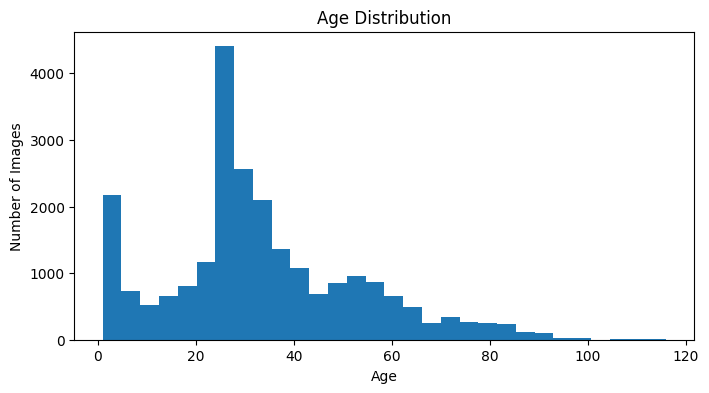

race distribution:
race
0    10078
1     4526
3     3975
2     3434
4     1692
Name: count, dtype: int64


In [8]:
print("Gender distribution:")
print(df["gender"].value_counts())

plt.figure(figsize=(8, 4))
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Images")
plt.show()
print("race distribution:")
print(df["race"].value_counts())

## Cell 8: Split Data into Training and Validation Sets

We use 80% data for training and 20% for validation.


In [9]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df["gender"]
)

print("Training samples:", train_df.shape)
print("Validation samples:", val_df.shape)


Training samples: (18964, 4)
Validation samples: (4741, 4)


## Cell 9: Create TensorFlow Dataset Pipeline

This modern `tf.data` pipeline avoids the old `ImageDataGenerator` multi-output problem.

For each image, it returns:

```python
image, {"age": age_label, "gender": gender_label}
```

This structure exactly matches our model outputs.


In [10]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_image_and_labels(image_path, age, gender, race):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)

    labels = {
        "age": tf.cast(age, tf.float32),
        "gender": tf.cast(gender, tf.float32),
         "race": tf.cast(race, tf.float32)
    }

    return image, labels


def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    ages = dataframe["age"].values
    genders = dataframe["gender"].values
    races = dataframe["race"].values # Changed variable name to avoid conflict with function param

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, ages, genders, races))
    dataset = dataset.map(load_image_and_labels, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [11]:
race_labels = {
    0: 'White',
    1: 'Black',
    2: 'Asian',
    3: 'Indian',
    4: 'Others' # (like Hispanic, Latino, Middle Eastern)
}

print("Race Labels:", race_labels)

Race Labels: {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}


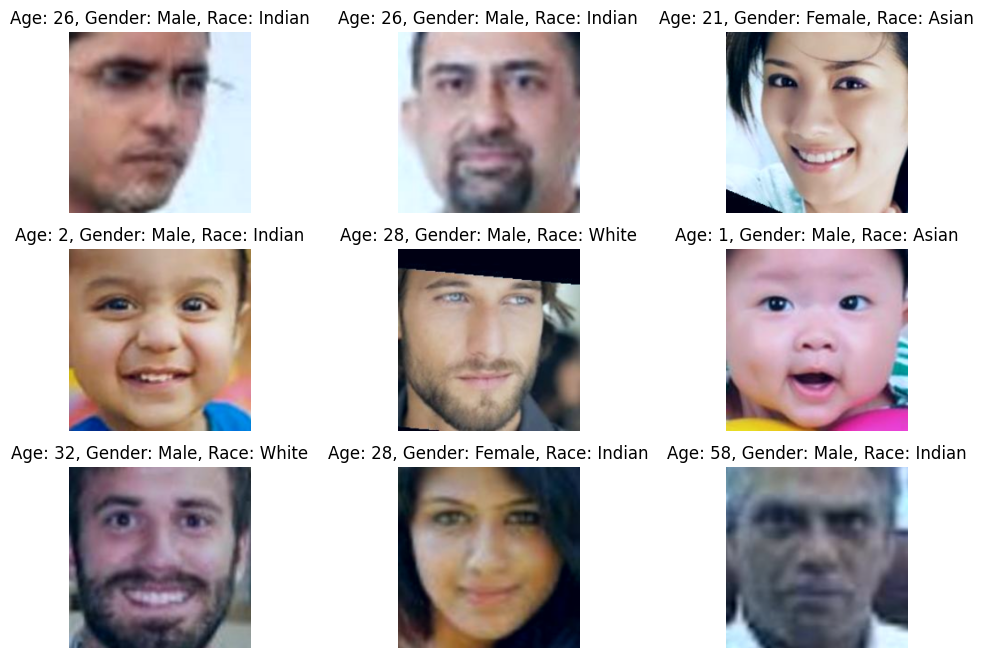

In [12]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 8))
    for i in range(9):
        img = images[i].numpy()
        # Reverse ResNet preprocessing approximately for display
        img = img[..., ::-1]
        img = img + np.array([103.939, 116.779, 123.68])
        img = np.clip(img, 0, 255).astype("uint8")

        age = int(labels["age"][i].numpy())
        gender = int(labels["gender"][i].numpy())
        gender_name = "Female" if gender == 1 else "Male"
        race = int(labels["race"][i].numpy())
        race_name = race_labels.get(race, "Unknown") # Use the race_labels dictionary

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Age: {age}, Gender: {gender_name}, Race: {race_name}")
        plt.axis("off")
    plt.show()

## Cell 11: Build ResNet50 Transfer Learning Model

We use **ResNet50 pretrained on ImageNet**.

Important points:

- `include_top=False` removes the original ImageNet classifier.
- `base_model.trainable=False` freezes ResNet50 layers.
- We add our own custom heads for age and gender.


In [13]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

age_output = layers.Dense(1, activation="linear", name="age")(x)
gender_output = layers.Dense(1, activation="sigmoid", name="gender")(x)
race_output = layers.Dense(5, activation="softmax", name="race")(x)

model = Model(inputs=inputs, outputs={"age": age_output, "gender": gender_output,"race": race_output})

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_1[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        257 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        257 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ race (Dense)        │ (None, 5)         │      1,285 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,769,927 (94.49 MB)

 Trainable params: 1,182,215 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Cell 12: Compile the Model

The model uses two losses:

1. **Age loss**: Mean Absolute Error because age is a regression problem.
2. **Gender loss**: Binary Crossentropy because gender is binary classification.

We also use loss weights so that gender learning is not ignored.


In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy",
        "race": "sparse_categorical_crossentropy" # Corrected loss for race
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"],
        "race": ["sparse_categorical_accuracy"] # Added metric for race
    },
    loss_weights={
        "age": 1.0,
        "gender": 5.0,
        "race": 1.0 # Added loss weight for race
    }
)

## Cell 13: Define Callbacks

Callbacks help improve training:

- **EarlyStopping** stops training if validation loss stops improving.
- **ModelCheckpoint** saves the best model.
- **ReduceLROnPlateau** reduces learning rate when training becomes stuck.


In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_resnet50_age_gender_model.keras",
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7
)


## Cell 14: Train the Model

This trains only the custom top layers while ResNet50 remains frozen.

Start with 10 epochs. You can increase it later.


In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 107s 146ms/step - age_loss: 12.4117 - age_mae: 12.4131 - gender_accuracy: 0.7797 - gender_loss: 0.5058 - loss: 17.0267 - race_loss: 2.0828 - race_sparse_categorical_accuracy: 0.3901 - val_age_loss: 8.8117 - val_age_mae: 8.8334 - val_gender_accuracy: 0.8650 - val_gender_loss: 0.3017 - val_loss: 11.4717 - val_race_loss: 1.1261 - val_race_sparse_categorical_accuracy: 0.5967 - learning_rate: 1.0000e-04
Epoch 2/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 75s 123ms/step - age_loss: 8.8398 - age_mae: 8.8418 - gender_accuracy: 0.8353 - gender_loss: 0.3811 - loss: 12.2853 - race_loss: 1.5394 - race_sparse_categorical_accuracy: 0.4982 - val_age_loss: 7.8201 - val_age_mae: 7.8524 - val_gender_accuracy: 0.8732 - val_gender_loss: 0.2790 - val_loss: 10.2302 - val_race_loss: 0.9790 - val_race_sparse_categorical_accuracy: 0.6516 - learning_rate: 1.0000e-04
Epoch 3/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 76s 123ms/step - age_loss: 8.2019 - age_mae: 8.2005 - gender_accuracy: 0.8577 - ge

## Cell 15: Plot Training Curves

This cell plots age error and gender accuracy.


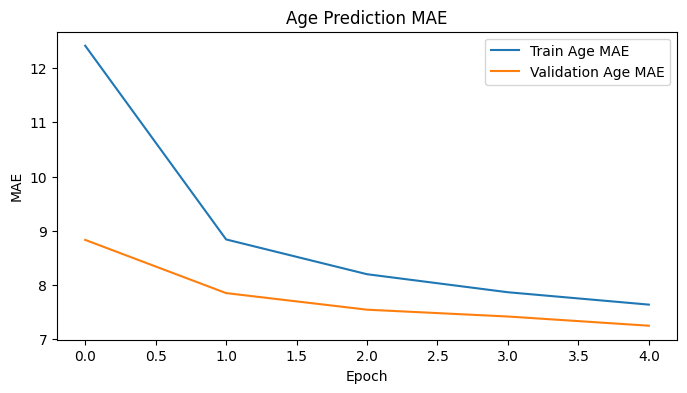

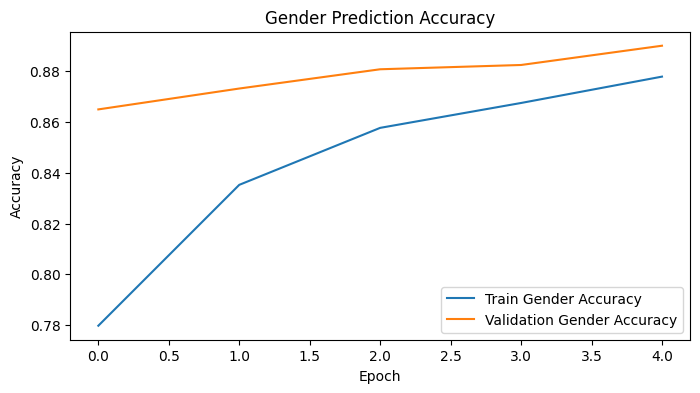

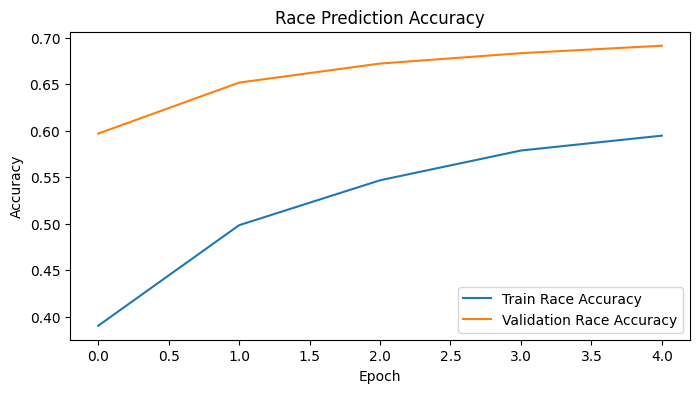

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["age_mae"], label="Train Age MAE")
plt.plot(history.history["val_age_mae"], label="Validation Age MAE")
plt.title("Age Prediction MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["gender_accuracy"], label="Train Gender Accuracy")
plt.plot(history.history["val_gender_accuracy"], label="Validation Gender Accuracy")
plt.title("Gender Prediction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["race_sparse_categorical_accuracy"], label="Train Race Accuracy")
plt.plot(history.history["val_race_sparse_categorical_accuracy"], label="Validation Race Accuracy")
plt.title("Race Prediction Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Cell 16: Fine-Tuning ResNet50

After training the custom head, we unfreeze the last few ResNet50 layers and train with a very small learning rate.

Fine-tuning can improve performance.


In [18]:
base_model.trainable = True

# Freeze earlier layers and fine-tune only last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss={
        "age": "mae",
        "gender": "binary_crossentropy",
        "race": "sparse_categorical_crossentropy" # Added loss for race
    },
    metrics={
        "age": ["mae"],
        "gender": ["accuracy"],
        "race": ["sparse_categorical_accuracy"] # Added metric for race
    },
    loss_weights={
        "age": 1.0,
        "gender": 5.0,
        "race": 1.0 # Added loss weight for race
    }
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 134s 186ms/step - age_loss: 8.3143 - age_mae: 8.3142 - gender_accuracy: 0.8536 - gender_loss: 0.3344 - loss: 11.2006 - race_loss: 1.2141 - race_sparse_categorical_accuracy: 0.5671 - val_age_loss: 7.2720 - val_age_mae: 7.2994 - val_gender_accuracy: 0.8950 - val_gender_loss: 0.2450 - val_loss: 9.4178 - val_race_loss: 0.8922 - val_race_sparse_categorical_accuracy: 0.6828 - learning_rate: 1.0000e-05
Epoch 2/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 103s 171ms/step - age_loss: 6.8589 - age_mae: 6.8583 - gender_accuracy: 0.8934 - gender_loss: 0.2564 - loss: 9.2696 - race_loss: 1.1292 - race_sparse_categorical_accuracy: 0.6001 - val_age_loss: 6.4738 - val_age_mae: 6.4901 - val_gender_accuracy: 0.9017 - val_gender_loss: 0.2301 - val_loss: 8.4920 - val_race_loss: 0.8499 - val_race_sparse_categorical_accuracy: 0.6956 - learning_rate: 1.0000e-05
Epoch 3/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 96s 159ms/step - age_loss: 6.1725 - age_mae: 6.1716 - gender_accuracy: 0.9104 - gender

## Cell 17: Evaluate the Model

This cell evaluates the final model on validation data.


In [19]:
results = model.evaluate(val_ds)
print("Evaluation Results:", results)


149/149 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - age_loss: 6.2287 - age_mae: 6.2464 - gender_accuracy: 0.9074 - gender_loss: 0.2232 - loss: 8.1537 - race_loss: 0.7869 - race_sparse_categorical_accuracy: 0.7228
Evaluation Results: [8.153707504272461, 6.228687763214111, 0.22322267293930054, 0.7869461178779602, 6.246413230895996, 0.9074035286903381, 0.7228432893753052]


## Cell 18: Predict Age and Gender on One Image

Upload or give the path of any face image and run this function.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


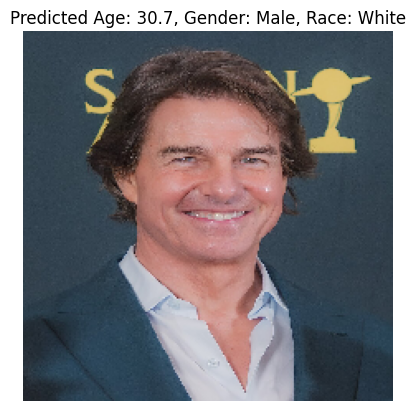

Predicted Age: 30.7
Predicted Gender: Male
Gender Probability Female: 0.000
Predicted Race: White
Race Probability: 0.824


In [27]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_age_gender(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    age = prediction["age"][0][0]
    gender_prob = prediction["gender"][0][0]
    gender = "Female" if gender_prob >= 0.5 else "Male"

    # Get race prediction
    race_probs = prediction["race"][0] # This will be an array of 5 probabilities
    predicted_race_idx = np.argmax(race_probs)
    predicted_race_label = race_labels.get(predicted_race_idx, "Unknown")
    max_race_prob = race_probs[predicted_race_idx]

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted Age: {age:.1f}, Gender: {gender}, Race: {predicted_race_label}")
    plt.show()

    print(f"Predicted Age: {age:.1f}")
    print(f"Predicted Gender: {gender}")
    print(f"Gender Probability Female: {gender_prob:.3f}")
    print(f"Predicted Race: {predicted_race_label}")
    print(f"Race Probability: {max_race_prob:.3f}")


# Example:
predict_age_gender('/content/Tom_Cruise_at_53rd_Saturn_Awards_2026-01.jpg')

## Cell 19: Save Final Model

This saves the final trained model.


In [21]:
model.save("resnet50_age_gender_final_model.keras")
print("Model saved successfully.")


Model saved successfully.


## Cell 20: Load Saved Model

Use this cell when you want to reuse the trained model later.


In [22]:
loaded_model = tf.keras.models.load_model("resnet50_age_gender_final_model.keras")
print("Model loaded successfully.")


Model loaded successfully.


# Summary

In this notebook, we built an end-to-end age and gender prediction system using:

- UTKFace dataset
- Kaggle secret-key method
- TensorFlow `tf.data` pipeline
- ResNet50 transfer learning
- Multi-output model
- Age regression
- Gender classification
- Fine-tuning
- Prediction function
- Model saving and loading
